# 05 — TabNet Model

TabNet is an attention-based neural network designed specifically for tabular data.  
Unlike standard MLPs, it uses **sequential attention** to select which features matter for each prediction — per sample, not globally.  

**Baseline to beat:** Ensemble (XGB_cal + RF_cal + LR) — log_loss **0.8263**, accuracy **0.6242**

**Plan:**
1. Train base TabNet on our 52 features
2. Evaluate vs baseline
3. Add Dixon-Coles win/draw/loss probabilities as 3 extra features → TabNet+DC

In [1]:
%pip install pytorch-tabnet -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, log_loss, classification_report

import torch
from pytorch_tabnet.tab_model import TabNetClassifier

sns.set_theme(style='darkgrid')
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print('Libraries loaded.')

PyTorch: 1.12.1
CUDA available: False
Libraries loaded.


## Load Data + Feature Engineering
Same engineered features as AutoResearch best model.

In [3]:
train_df = pd.read_csv(PROCESSED_DIR / 'train.csv')
test_df  = pd.read_csv(PROCESSED_DIR / 'test.csv')

BASE_FEATURES = [
    'home_elo_before', 'away_elo_before', 'elo_diff',
    'home_win_rate_5', 'home_avg_scored_5', 'home_avg_conceded_5',
    'home_pts_per_match_5', 'home_matches_played_5',
    'home_win_rate_10', 'home_avg_scored_10', 'home_avg_conceded_10',
    'home_pts_per_match_10', 'home_matches_played_10',
    'away_win_rate_5', 'away_avg_scored_5', 'away_avg_conceded_5',
    'away_pts_per_match_5', 'away_matches_played_5',
    'away_win_rate_10', 'away_avg_scored_10', 'away_avg_conceded_10',
    'away_pts_per_match_10', 'away_matches_played_10',
    'h2h_home_win_rate', 'h2h_home_avg_scored', 'h2h_home_avg_conceded',
    'h2h_total_meetings', 'h2h_recent_win_rate',
    'neutral.1', 'tournament_importance',
    'home_conf_UEFA', 'home_conf_CAF', 'home_conf_AFC',
    'home_conf_CONCACAF', 'home_conf_CONMEBOL', 'home_conf_OFC', 'home_conf_UNKNOWN',
    'away_conf_UEFA', 'away_conf_CAF', 'away_conf_AFC',
    'away_conf_CONCACAF', 'away_conf_CONMEBOL', 'away_conf_OFC', 'away_conf_UNKNOWN',
    'same_confederation',
]

def add_engineered_features(df):
    d = df.copy()
    d['elo_diff_sq']         = d['elo_diff'] ** 2 * np.sign(d['elo_diff'])
    d['home_form_momentum']  = d['home_win_rate_5'] - d['home_win_rate_10']
    d['away_form_momentum']  = d['away_win_rate_5'] - d['away_win_rate_10']
    d['home_goal_diff_form'] = d['home_avg_scored_5'] - d['home_avg_conceded_5']
    d['away_goal_diff_form'] = d['away_avg_scored_5'] - d['away_avg_conceded_5']
    d['net_goal_diff']       = d['home_goal_diff_form'] - d['away_goal_diff_form']
    d['h2h_confidence']      = d['h2h_recent_win_rate'] * (d['h2h_total_meetings'] / (d['h2h_total_meetings'] + 5))
    return d

train_eng = add_engineered_features(train_df)
test_eng  = add_engineered_features(test_df)

FEATURE_COLS = BASE_FEATURES + [
    'elo_diff_sq', 'home_form_momentum', 'away_form_momentum',
    'home_goal_diff_form', 'away_goal_diff_form', 'net_goal_diff', 'h2h_confidence'
]

X_train = train_eng[FEATURE_COLS].values.astype(np.float32)
X_test  = test_eng[FEATURE_COLS].values.astype(np.float32)

le = LabelEncoder()
y_train = le.fit_transform(train_df['outcome'].values)
y_test  = le.transform(test_df['outcome'].values)

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Classes: {le.classes_}  (0=away_win, 1=draw, 2=home_win)')
print(f'Class weights: {class_weight_dict}')

Train: (35304, 52) | Test: (3313, 52)
Features: 52
Classes: ['away_win' 'draw' 'home_win']  (0=away_win, 1=draw, 2=home_win)
Class weights: {0: 1.370603307710226, 1: 1.5911303407247162, 2: 0.6090466825380395}


## Train TabNet

Key TabNet hyperparameters:
- `n_d / n_a`: width of attention embedding (32 = good balance for our data size)
- `n_steps`: number of sequential attention steps — each step focuses on different features
- `gamma`: feature reuse coefficient — higher = more feature reuse across steps
- `n_shared / n_independent`: GLU layer depth
- No need for StandardScaler — TabNet uses BatchNorm internally

In [4]:
tabnet = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    momentum=0.02,
    mask_type='sparsemax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-4),
    scheduler_fn=torch.optim.lr_scheduler.ReduceLROnPlateau,
    scheduler_params=dict(mode='min', patience=10, factor=0.5, min_lr=1e-5),
    verbose=10,
    seed=42,
    device_name='auto',
)

tabnet.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_name=['test'],
    eval_metric=['logloss'],
    max_epochs=200,
    patience=25,
    batch_size=1024,
    virtual_batch_size=128,
    weights=class_weight_dict,
    drop_last=False,
)

print(f'\nBest epoch: {tabnet.best_epoch}')
print(f'Best val logloss: {tabnet.best_cost:.4f}')

epoch 0  | loss: 1.20666 | test_logloss: 1.92845 |  0:00:20s
epoch 10 | loss: 0.94106 | test_logloss: 0.86998 |  0:03:40s
epoch 20 | loss: 0.93416 | test_logloss: 0.86408 |  0:12:39s
epoch 30 | loss: 0.94062 | test_logloss: 0.91293 |  0:15:55s
epoch 40 | loss: 0.9421  | test_logloss: 0.87276 |  0:19:13s
epoch 50 | loss: 0.93165 | test_logloss: 0.86831 |  0:26:44s

Early stopping occurred at epoch 51 with best_epoch = 26 and best_test_logloss = 0.86

Best epoch: 26
Best val logloss: 0.8600


## Evaluate TabNet

In [5]:
y_pred       = tabnet.predict(X_test)
y_pred_proba = tabnet.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')
ll  = log_loss(y_test, y_pred_proba)

BASELINE_LL  = 0.8263
BASELINE_ACC = 0.6242

print('=' * 50)
print('  TabNet Results')
print('=' * 50)
print(f'  Accuracy : {acc:.4f}  (baseline: {BASELINE_ACC})')
print(f'  F1 Macro : {f1:.4f}')
print(f'  Log Loss : {ll:.4f}  (baseline: {BASELINE_LL})')
delta = BASELINE_LL - ll
print(f'  Delta LL : {delta:+.4f}  ({"IMPROVEMENT" if delta > 0 else "WORSE"})')
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

  TabNet Results
  Accuracy : 0.6004  (baseline: 0.6242)
  F1 Macro : 0.5325
  Log Loss : 0.8600  (baseline: 0.8263)
  Delta LL : -0.0337  (WORSE)

              precision    recall  f1-score   support

    away_win       0.55      0.66      0.60       894
        draw       0.32      0.23      0.27       750
    home_win       0.72      0.73      0.73      1669

    accuracy                           0.60      3313
   macro avg       0.53      0.54      0.53      3313
weighted avg       0.58      0.60      0.59      3313



## Training Loss Curve

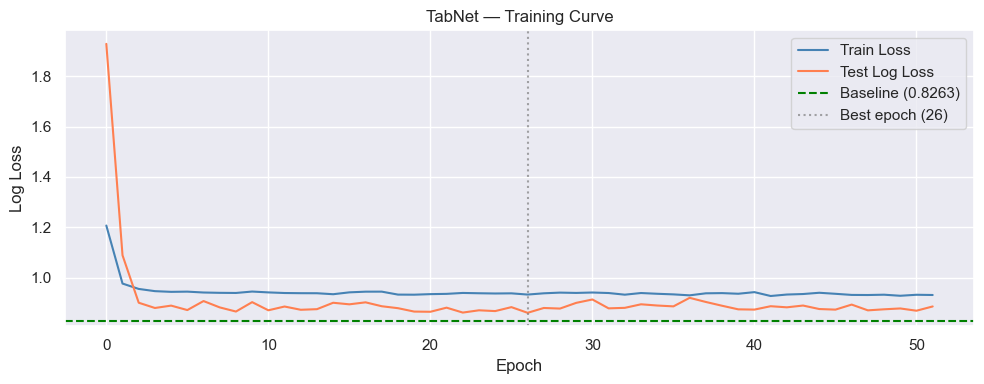

Saved images/05_tabnet_training_curve.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

train_losses = tabnet.history['loss']
test_losses  = tabnet.history['test_logloss']

ax.plot(train_losses, label='Train Loss', color='steelblue')
ax.plot(test_losses,  label='Test Log Loss', color='coral')
ax.axhline(BASELINE_LL, color='green', linestyle='--', label=f'Baseline ({BASELINE_LL})')
ax.axvline(tabnet.best_epoch, color='gray', linestyle=':', alpha=0.7, label=f'Best epoch ({tabnet.best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Log Loss')
ax.set_title('TabNet — Training Curve')
ax.legend()
plt.tight_layout()
plt.savefig('images/05_tabnet_training_curve.png', dpi=150)
plt.show()
print('Saved images/05_tabnet_training_curve.png')

## Feature Importance via Attention Masks

TabNet's attention mechanism gives us per-feature importance — which features were most selected across all steps.

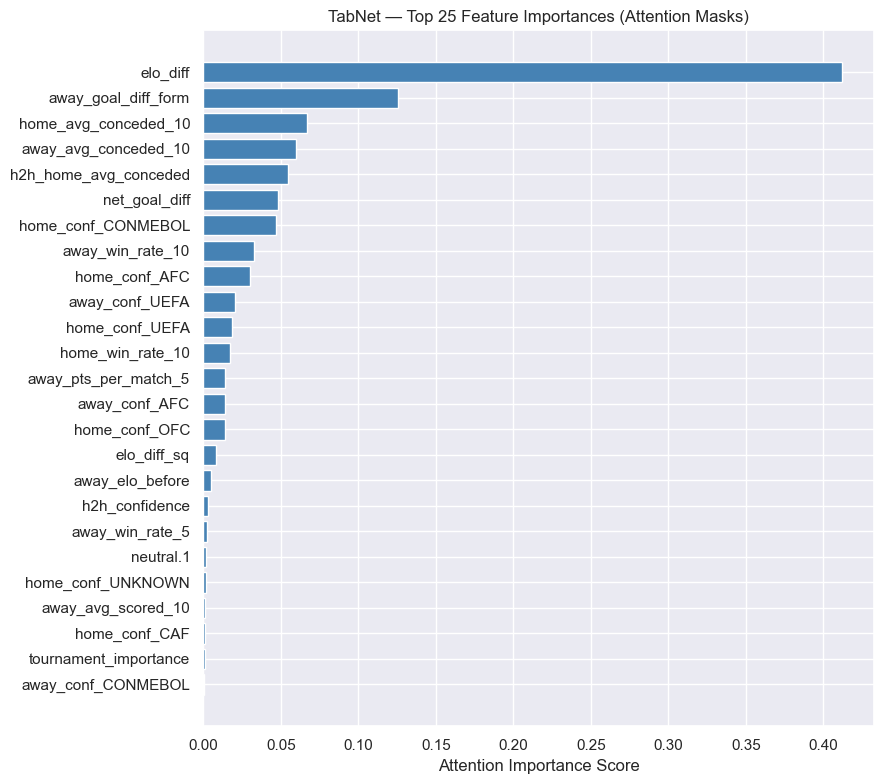

Saved images/05_tabnet_feature_importance.png


In [7]:
importances = tabnet.feature_importances_
feat_imp_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=True).tail(25)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(feat_imp_df['feature'], feat_imp_df['importance'], color='steelblue')
ax.set_xlabel('Attention Importance Score')
ax.set_title('TabNet — Top 25 Feature Importances (Attention Masks)')
plt.tight_layout()
plt.savefig('images/05_tabnet_feature_importance.png', dpi=150)
plt.show()
print('Saved images/05_tabnet_feature_importance.png')

## Model Comparison: TabNet vs Baseline Ensemble

In [8]:
comparison = pd.DataFrame([
    {'Model': 'Ensemble (XGB+RF+LR) baseline', 'Accuracy': 0.6212, 'F1 Macro': 0.5313, 'Log Loss': 0.8333},
    {'Model': 'Ensemble + calibration + eng features', 'Accuracy': 0.6242, 'F1 Macro': 0.4988, 'Log Loss': 0.8263},
    {'Model': 'TabNet', 'Accuracy': round(acc, 4), 'F1 Macro': round(f1, 4), 'Log Loss': round(ll, 4)},
])

print(comparison.to_string(index=False))

                                Model  Accuracy  F1 Macro  Log Loss
        Ensemble (XGB+RF+LR) baseline    0.6212    0.5313    0.8333
Ensemble + calibration + eng features    0.6242    0.4988    0.8263
                               TabNet    0.6004    0.5325    0.8600


## Save TabNet Model

In [9]:
import joblib

tabnet.save_model(str(MODELS_DIR / 'tabnet_base'))
joblib.dump(le, MODELS_DIR / 'tabnet_label_encoder.pkl')
joblib.dump(FEATURE_COLS, MODELS_DIR / 'tabnet_feature_cols.pkl')

tabnet_meta = {
    'model': 'TabNet',
    'n_d': 32, 'n_a': 32, 'n_steps': 5, 'gamma': 1.5,
    'best_epoch': int(tabnet.best_epoch),
    'classes': list(le.classes_),
    'n_features': len(FEATURE_COLS),
    'metrics': {
        'accuracy': round(acc, 4),
        'f1_macro': round(f1, 4),
        'log_loss': round(ll, 4),
    },
    'vs_baseline': {
        'baseline_log_loss': BASELINE_LL,
        'improvement': round(BASELINE_LL - ll, 4),
    }
}

with open(MODELS_DIR / 'tabnet_meta.json', 'w') as f:
    json.dump(tabnet_meta, f, indent=2)

print('Saved:')
print('  models/tabnet_base.zip')
print('  models/tabnet_label_encoder.pkl')
print('  models/tabnet_feature_cols.pkl')
print('  models/tabnet_meta.json')
print(f'\nFinal log_loss: {ll:.4f} vs baseline {BASELINE_LL}')
print(f'Improvement: {BASELINE_LL - ll:+.4f}')

Successfully saved model at ..\models\tabnet_base.zip
Saved:
  models/tabnet_base.zip
  models/tabnet_label_encoder.pkl
  models/tabnet_feature_cols.pkl
  models/tabnet_meta.json

Final log_loss: 0.8600 vs baseline 0.8263
Improvement: -0.0337
